<a href="https://colab.research.google.com/github/OnchariMillicent/Financial-Loan-Risk-Analysis/blob/main/financial_loan_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Title: **Predicting Loan Approval Using Random Forest Machine Learning**

## **Project Overview**

This project developed and evaluated a machine learning model to predict loan approval decisions using applicants' demographic, financial, and credit-related information.

A Random Forest classifier was trained using a complete machine learning pipeline that included data preprocessing, exploratory data analysis, feature engineering, cross-validation, and hyperparameter tuning with GridSearchCV.

The final model achieved an accuracy of 98.82%, precision of 98.51%, recall of 96.51%, and an F1-score of 97.50%, demonstrating excellent predictive performance and strong generalization to unseen data.

Feature importance analysis revealed that Risk Score, Total Debt-to-Income Ratio, Monthly Income, and Annual Income were the most influential factors driving loan approval decisions, while demographic characteristics contributed relatively little to the model's predictions.

These findings indicate that the model can serve as an effective decision-support tool, enabling financial institutions to improve the consistency, efficiency, and accuracy of credit risk assessments while supporting more informed lending decisions.

## **Introduction**

Loan approval is a critical process for financial institutions, requiring a balance between minimizing credit risk and providing timely decisions to applicants. As the volume and complexity of loan applications continue to increase, machine learning offers an opportunity to support traditional underwriting by identifying patterns in historical lending data and generating consistent, data-driven predictions.

This project applies a Random Forest classification model to predict loan approval outcomes using applicants' financial, credit, and demographic information. The analysis follows a complete machine learning workflow, including exploratory data analysis, data preprocessing, feature engineering, model training, hyperparameter tuning, and performance evaluation.

The goal is to assess whether machine learning can improve the efficiency, consistency, and reliability of loan approval decisions while providing actionable insights into the factors that most influence lending outcomes.

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [ ]:
# Imports
#install pipeline
#!pip install pipeline

In [ ]:
#import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    LabelEncoder
)

# Model selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    StratifiedKFold,
    KFold
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Model
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# loading data
data = pd.read_csv('financial_loan_data.csv')

In [ ]:
# displaying the first 5 rows of the dataset
data.head(10)

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0
5,37,"$178,310.00",626,Self-Employed,Master,16,15433,72,Married,0,...,14859.166667,0.756079,5,27071,0.217433,0.217601,385.577074,0.075211,1,44.0
6,58,"$51,250.00",564,Employed,High School,39,12741,48,Married,0,...,4270.833333,0.884275,5,21730,0.225741,0.205271,391.300352,0.170529,0,50.0
7,49,"$97,345.00",516,Employed,High School,23,19634,12,Divorced,5,...,8112.083333,0.933492,5,38621,0.226634,0.209113,1827.360055,0.260767,1,42.4
8,34,"$116,841.00",603,Employed,Bachelor,12,55353,60,Divorced,5,...,9736.750000,0.728397,3,7711,0.258853,0.291539,1762.199026,0.246509,0,61.0
9,46,"$40,615.00",612,Employed,NaN,19,25443,12,Married,4,...,3384.583333,0.615323,3,116812,0.184443,0.197271,2353.577424,0.903384,0,53.0


In [ ]:
# checking the shape of the dataset
data.shape

(20000, 35)

In [ ]:
# listing all the columns in the dataset
data.columns.to_list()

['Age',
 'AnnualIncome',
 'CreditScore',
 'EmploymentStatus',
 'EducationLevel',
 'Experience',
 'LoanAmount',
 'LoanDuration',
 'MaritalStatus',
 'NumberOfDependents',
 'HomeOwnershipStatus',
 'MonthlyDebtPayments',
 'CreditCardUtilizationRate',
 'NumberOfOpenCreditLines',
 'NumberOfCreditInquiries',
 'DebtToIncomeRatio',
 'BankruptcyHistory',
 'LoanPurpose',
 'PreviousLoanDefaults',
 'PaymentHistory',
 'LengthOfCreditHistory',
 'SavingsAccountBalance',
 'CheckingAccountBalance',
 'TotalAssets',
 'TotalLiabilities',
 'MonthlyIncome',
 'UtilityBillsPaymentHistory',
 'JobTenure',
 'NetWorth',
 'BaseInterestRate',
 'InterestRate',
 'MonthlyLoanPayment',
 'TotalDebtToIncomeRatio',
 'LoanApproved',
 'RiskScore']

In [ ]:
# fixing the column naming issues
data = data.rename(columns={
    "Age": "age",
    "AnnualIncome": "annual_income",
    "CreditScore": "credit_score",
    "EmploymentStatus": "employment_status",
    "EducationLevel": "education_level",
    "Experience": "experience",
    "LoanAmount": "loan_amount",
    "LoanDuration": "loan_duration",
    "MaritalStatus": "marital_status",
    "NumberOfDependents": "number_of_dependents",
    "HomeOwnershipStatus": "home_ownership_status",
    "MonthlyDebtPayments": "monthly_debt_payments",
    "CreditCardUtilizationRate": "credit_card_utilization_rate",
    "NumberOfOpenCreditLines": "number_of_open_credit_lines",
    "NumberOfCreditInquiries": "number_of_credit_inquiries",
    "DebtToIncomeRatio": "debt_to_income_ratio",
    "BankruptcyHistory": "bankruptcy_history",
    "LoanPurpose": "loan_purpose",
    "PreviousLoanDefaults": "previous_loan_defaults",
    "PaymentHistory": "payment_history",
    "LengthOfCreditHistory": "length_of_credit_history",
    "SavingsAccountBalance": "savings_account_balance",
    "CheckingAccountBalance": "checking_account_balance",
    "TotalAssets": "total_assets",
    "TotalLiabilities": "total_liabilities",
    "MonthlyIncome": "monthly_income",
    "UtilityBillsPaymentHistory": "utility_bills_payment_history",
    "JobTenure": "job_tenure",
    "NetWorth": "net_worth",
    "BaseInterestRate": "base_interest_rate",
    "InterestRate": "interest_rate",
    "MonthlyLoanPayment": "monthly_loan_payment",
    "TotalDebtToIncomeRatio": "total_debt_to_income_ratio",
    "LoanApproved": "loan_approved",
    "RiskScore": "risk_score"
})

In [ ]:
data.columns.tolist()

['age',
 'annual_income',
 'credit_score',
 'employment_status',
 'education_level',
 'experience',
 'loan_amount',
 'loan_duration',
 'marital_status',
 'number_of_dependents',
 'home_ownership_status',
 'monthly_debt_payments',
 'credit_card_utilization_rate',
 'number_of_open_credit_lines',
 'number_of_credit_inquiries',
 'debt_to_income_ratio',
 'bankruptcy_history',
 'loan_purpose',
 'previous_loan_defaults',
 'payment_history',
 'length_of_credit_history',
 'savings_account_balance',
 'checking_account_balance',
 'total_assets',
 'total_liabilities',
 'monthly_income',
 'utility_bills_payment_history',
 'job_tenure',
 'net_worth',
 'base_interest_rate',
 'interest_rate',
 'monthly_loan_payment',
 'total_debt_to_income_ratio',
 'loan_approved',
 'risk_score']

In [ ]:
# investigating the null values
data.isnull().sum()

,0
age,0
annual_income,0
credit_score,0
employment_status,0
education_level,901
experience,0
loan_amount,0
loan_duration,0
marital_status,1331
number_of_dependents,0


#### **Null Observations**
From the output above, we have found out that some columns have null values. i.e, Educal level with 901, marital status with 1331, and savings account balance with 572. We will investigate each columns further to understand the nulls and decide on how we should handle them.

In [ ]:
# Investigating education null values
data["education_level"].value_counts(dropna=False)

,count
education_level,
Bachelor,5804
High School,5592
Associate,3850
Master,2933
Doctorate,920
NaN,901


In [ ]:
education_missing = data[data["education_level"].isna()]

In [ ]:
education_missing.head(20)

,age,annual_income,credit_score,employment_status,education_level,experience,loan_amount,loan_duration,marital_status,number_of_dependents,...,monthly_income,utility_bills_payment_history,job_tenure,net_worth,base_interest_rate,interest_rate,monthly_loan_payment,total_debt_to_income_ratio,loan_approved,risk_score
9,46,40615.0,612,Employed,NaN,19,25443,12,Married,4,...,3384.583333,0.615323,3,116812,0.184443,0.197271,2353.577424,0.903384,0,53.0
28,32,35498.0,622,Employed,NaN,10,11136,36,Married,0,...,2958.166667,0.703668,3,2705,0.185136,0.164846,394.178185,0.369208,0,48.0
31,62,73843.0,667,Unemployed,NaN,37,44668,60,Single,1,...,6153.583333,0.944649,5,3068,0.216168,0.234603,1271.053755,0.269608,0,62.0
40,48,38453.0,595,Unemployed,NaN,26,30517,48,Divorced,0,...,3204.416667,0.793543,6,42871,0.228017,0.226231,971.823060,0.478035,0,54.0
52,31,36057.0,592,Employed,NaN,11,29501,36,Married,3,...,3004.750000,0.731987,4,1500,0.218501,0.214285,1117.953612,0.499860,0,51.0
79,18,40050.0,545,Self-Employed,NaN,0,112253,48,Married,1,...,3337.500000,0.937030,4,7672,0.334753,0.358486,4432.382784,1.449703,0,64.0
80,37,40784.0,618,Employed,NaN,14,41465,72,Married,0,...,3398.666667,0.831501,4,172083,0.247465,0.292763,1228.160165,0.470232,0,45.0
83,33,17676.0,540,Employed,NaN,8,17801,48,Married,4,...,1473.000000,0.878423,5,48674,0.242801,0.243881,584.170971,0.550014,0,55.0
169,30,25658.0,583,Employed,NaN,7,6423,36,Married,3,...,2138.166667,0.628162,5,57777,0.199923,0.197496,237.882996,0.286172,0,51.0
171,30,50657.0,591,Employed,NaN,4,20536,48,Married,2,...,4221.416667,0.696183,11,107416,0.220036,0.195914,620.455541,0.298112,0,46.0


In [ ]:
education_missing.shape

(901, 35)

In [ ]:
education_missing.describe().T

,count,mean,std,min,25%,50%,75%,max
age,901.0,38.649279,12.256661,18.000000,30.000000,39.000000,47.000000,8.000000e+01
annual_income,901.0,45374.487236,24487.043636,15000.000000,27339.000000,40520.000000,57546.000000,2.182310e+05
credit_score,901.0,565.554939,52.858412,381.000000,533.000000,573.000000,607.000000,6.950000e+02
experience,901.0,16.579356,11.781698,0.000000,7.000000,16.000000,24.000000,5.500000e+01
loan_amount,901.0,26790.651498,14133.148525,4970.000000,17203.000000,23942.000000,33112.000000,1.131540e+05
loan_duration,901.0,54.832408,25.515218,12.000000,36.000000,48.000000,72.000000,1.200000e+02
number_of_dependents,901.0,1.526082,1.368956,0.000000,0.000000,1.000000,2.000000,5.000000e+00
monthly_debt_payments,901.0,480.350721,253.084213,105.000000,303.000000,422.000000,593.000000,1.754000e+03
credit_card_utilization_rate,901.0,0.289234,0.154797,0.010489,0.168391,0.276478,0.387677,7.662311e-01
number_of_open_credit_lines,901.0,3.128746,1.826674,0.000000,2.000000,3.000000,4.000000,1.000000e+01


In [ ]:
data.groupby(data["education_level"].isna())["loan_approved"].agg(
    ["count", "mean"]
)

,count,mean
education_level,,
False,19099,0.250275
True,901,0.000000


In [ ]:
data.groupby(data["education_level"].isna())[
    ["credit_score", "risk_score", "annual_income", "loan_amount"]
].mean()

,credit_score,risk_score,annual_income,loan_amount
education_level,,,,
False,571.898162,50.610325,59811.878004,24792.867637
True,565.554939,54.083241,45374.487236,26790.651498


#### **Key Obseravtions**
From the above lines of code, i realized that the columns with no education level mentioned had 0 loan approval. I tried to compare that with those with education level status alongside other columns like annual income, credit scores, risk scores, and loan amounts to understand if the lack of education level affected the eligibility of these customers to receive a loan.

From the output, I observed that records with missing education information had a slightly lower average credit score than records with known education levels (565.55 vs. 571.90), indicating a modest difference in credit profile between the two groups, although the difference alone does not establish that education level influenced credit scores.



Filling nulls with unkwown

In [ ]:
data["education_level"] = data["education_level"].fillna("Unknown")

In [ ]:
data['education_level'].isnull().sum()

np.int64(0)

#### **Inspecting and fixing the Marital Status Nulls**

In [ ]:
data["marital_status"].value_counts(dropna=False)

,count
marital_status,
Married,9370
Single,5665
Divorced,2704
NaN,1331
Widowed,930


In [ ]:
# Creating the missing group
marital_missing = data[data["marital_status"].isna()]
marital_missing

,age,annual_income,credit_score,employment_status,education_level,experience,loan_amount,loan_duration,marital_status,number_of_dependents,...,monthly_income,utility_bills_payment_history,job_tenure,net_worth,base_interest_rate,interest_rate,monthly_loan_payment,total_debt_to_income_ratio,loan_approved,risk_score
2,47,40724.0,570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
22,40,114216.0,635,Employed,Doctorate,17,9809,60,NaN,3,...,9518.000000,0.851839,10,2482,0.197309,0.201114,260.486905,0.087359,1,46.4
24,33,39676.0,555,Employed,Master,12,47795,60,NaN,1,...,3306.333333,0.583599,4,81172,0.275295,0.253474,1412.597891,0.487428,0,60.0
56,29,31683.0,498,Employed,Associate,5,10566,24,NaN,2,...,2640.250000,0.829093,5,154938,0.236566,0.209471,542.666515,0.274848,0,48.0
61,37,38513.0,600,Self-Employed,High School,16,21225,48,NaN,2,...,3209.416667,0.875203,4,16183,0.216225,0.231104,681.577143,0.328588,0,52.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19928,46,107562.0,609,Employed,High School,22,38997,60,NaN,0,...,8963.500000,0.871250,7,2377,0.239497,0.231974,1103.771871,0.153486,0,53.0
19946,36,84916.0,599,Employed,Associate,12,12026,48,NaN,0,...,7076.333333,0.920436,9,6650,0.207526,0.249031,398.098085,0.145146,0,64.0
19974,27,61451.0,575,Employed,High School,6,15652,36,NaN,0,...,5120.916667,0.867475,7,1198,0.213152,0.176556,563.157162,0.169532,0,49.0
19985,28,41949.0,634,Employed,Bachelor,9,32844,48,NaN,1,...,3495.750000,0.955501,4,5467,0.210844,0.199563,998.689435,0.412126,0,49.0


In [ ]:
marital_missing.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1331.0,39.712998,11.072297,18.000000,32.000000,40.000000,47.000000,7.400000e+01
annual_income,1331.0,59337.942149,42137.691744,15000.000000,31359.000000,47458.000000,75401.500000,4.224800e+05
credit_score,1331.0,570.725770,50.527153,392.000000,540.000000,578.000000,606.000000,6.960000e+02
experience,1331.0,17.394440,10.850104,0.000000,9.000000,17.000000,24.500000,5.600000e+01
loan_amount,1331.0,24783.937641,13661.361476,3961.000000,15483.500000,21906.000000,30209.500000,1.298600e+05
loan_duration,1331.0,54.329076,25.045821,12.000000,36.000000,48.000000,72.000000,1.200000e+02
number_of_dependents,1331.0,1.522164,1.368303,0.000000,0.000000,1.000000,2.000000,5.000000e+00
monthly_debt_payments,1331.0,445.693464,231.113895,88.000000,281.000000,396.000000,548.500000,1.654000e+03
credit_card_utilization_rate,1331.0,0.290341,0.160669,0.000974,0.164907,0.268728,0.396409,8.030044e-01
number_of_open_credit_lines,1331.0,3.024042,1.676290,0.000000,2.000000,3.000000,4.000000,1.000000e+01


In [ ]:
# comparing loan approvals of known vs missing marital status
data.groupby(data["marital_status"].isna())["loan_approved"].agg(["count", "mean"])


,count,mean
marital_status,,
False,18669,0.238577
True,1331,0.244929


In [ ]:
data.groupby(data["marital_status"].isna())[
    ["credit_score", "risk_score", "annual_income", "loan_amount"]
].mean()

,credit_score,risk_score,annual_income,loan_amount
marital_status,,,,
False,571.675612,50.775232,59148.892281,24889.920992
True,570.725770,50.648234,59337.942149,24783.937641


#### **Observation:**
 Records with missing marital status show very similar financial and credit characteristics to records with known marital status. The average credit score, risk score, income, loan amount, and loan approval rate differ only marginally between the two groups, suggesting that the missing values do not represent a substantially different customer segment.

In [ ]:
# Fixing the marital status null values
data["marital_status"] = data["marital_status"].fillna("Unknown")
data["marital_status"].isna().sum()

np.int64(0)

In [ ]:
data["marital_status"].value_counts(dropna=False)

,count
marital_status,
Married,9370
Single,5665
Divorced,2704
Unknown,1331
Widowed,930


#### **Investigating and Fixing the Savings Account Balance nulls**

In [ ]:
data["savings_account_balance"].isna().sum()

np.int64(572)

In [ ]:
# Creating the missing group variable
savings_missing = data[data['savings_account_balance'].isnull()]

In [ ]:
savings_missing.describe().T

,count,mean,std,min,25%,50%,75%,max
age,572.0,39.667832,11.424379,18.000000,32.000000,39.000000,48.000000,78.000000
annual_income,572.0,58954.416084,39242.310462,15000.000000,32325.000000,49402.000000,76110.000000,300000.000000
credit_score,572.0,576.183566,47.956594,402.000000,547.000000,582.000000,610.000000,691.000000
experience,572.0,17.534965,11.284593,0.000000,9.000000,17.000000,25.000000,57.000000
loan_amount,572.0,25642.641608,13333.269495,5525.000000,15952.000000,23103.000000,31781.250000,106945.000000
loan_duration,572.0,54.020979,23.719897,12.000000,36.000000,48.000000,63.000000,120.000000
number_of_dependents,572.0,1.515734,1.372011,0.000000,0.000000,1.000000,3.000000,5.000000
monthly_debt_payments,572.0,457.180070,234.136519,78.000000,289.000000,415.500000,563.500000,1572.000000
credit_card_utilization_rate,572.0,0.285754,0.164332,0.013741,0.157479,0.265065,0.396367,0.858539
number_of_open_credit_lines,572.0,2.947552,1.742850,0.000000,2.000000,3.000000,4.000000,10.000000


In [ ]:
# comparing known and missing saving balance
data.groupby(data['savings_account_balance'].isna())['loan_approved'].agg(['count', 'mean'])

,count,mean
savings_account_balance,,
False,19428,0.238264
True,572,0.263986


In [ ]:
data.groupby(data['savings_account_balance'].isna())[['credit_score', 'risk_score', 'annual_income', 'loan_amount']].mean()

,credit_score,risk_score,annual_income,loan_amount
savings_account_balance,,,,
False,571.477816,50.780605,59167.569745,24860.498507
True,576.183566,50.297203,58954.416084,25642.641608


#### **Observation:**
 Records with missing savings account balances have broadly similar financial and credit characteristics to records with known savings balances. Although the missing group has a slightly higher average credit score and loan approval rate, the differences across the key variables are relatively small, suggesting no strong evidence of systematic missingness.

In [ ]:
# Fixing the null values
# Finding the median saving account balance from the known values
data["savings_account_balance"].median()

2988.5

In [ ]:
# Using the median saving account balance to fix the nulls
data["savings_account_balance"] = data["savings_account_balance"].fillna(
    data["savings_account_balance"].median()
)

In [ ]:
data["savings_account_balance"].isna().sum()

np.int64(0)

In [ ]:
data["savings_account_balance"].describe()

,savings_account_balance
count,20000.000000
mean,4893.073900
std,6541.095515
min,73.000000
25%,1576.000000
50%,2988.500000
75%,5701.000000
max,200089.000000


### **Inspecting the whole dataset for any nulls**

In [ ]:
data.isna().sum()

,0
age,0
annual_income,0
credit_score,0
employment_status,0
education_level,0
experience,0
loan_amount,0
loan_duration,0
marital_status,0
number_of_dependents,0


In [ ]:
# inspecting each column's data type
data.dtypes

,0
age,int64
annual_income,float64
credit_score,int64
employment_status,object
education_level,object
experience,int64
loan_amount,int64
loan_duration,int64
marital_status,object
number_of_dependents,int64


After analyzing the columns data types, we have annual income as object whic shoul be either a float or numerical. We will investigate that and fix the issue.

In [ ]:
data['AnnualIncome'].unique()[:20]

array(['$39,948.00', '$39,709.00', '$40,724.00', '$69,084.00',
       '$103,264.00', '$178,310.00', '$51,250.00', '$97,345.00',
       '$116,841.00', '$40,615.00', '$73,646.00', '$15,000.00',
       '$74,453.00', '$100,508.00', '$47,624.00', '$56,650.00',
       '$50,042.00', '$142,326.00', '$16,021.00', '$34,698.00'],
      dtype=object)

The issue of having annual income as object result from the currency signs and the comas present and we will fix that.

In [ ]:
# Fixing the annual income column
data["AnnualIncome"] = (
    data["AnnualIncome"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [ ]:
data['AnnualIncome'].dtype

dtype('float64')

In [ ]:
# checking the info of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            20000 non-null  int64  
 1   annual_income                  20000 non-null  float64
 2   credit_score                   20000 non-null  int64  
 3   employment_status              20000 non-null  object 
 4   education_level                20000 non-null  object 
 5   experience                     20000 non-null  int64  
 6   loan_amount                    20000 non-null  int64  
 7   loan_duration                  20000 non-null  int64  
 8   marital_status                 20000 non-null  object 
 9   number_of_dependents           20000 non-null  int64  
 10  home_ownership_status          20000 non-null  object 
 11  monthly_debt_payments          20000 non-null  int64  
 12  credit_card_utilization_rate   20000 non-null 

In [ ]:
# checking for duplicates
data.duplicated().sum()

np.int64(0)

**Categorizing features by type**

In [ ]:
# Target variable
target_feature = ["loan_approved"]

In [ ]:
# Numerical Variables
num_features = [
    "age",
    "annual_income",
    "credit_score",
    "experience",
    "loan_amount",
    "loan_duration",
    "number_of_dependents",
    "monthly_debt_payments",
    "credit_card_utilization_rate",
    "number_of_open_credit_lines",
    "number_of_credit_inquiries",
    "debt_to_income_ratio",
    "previous_loan_defaults",
    "payment_history",
    "length_of_credit_history",
    "savings_account_balance",
    "checking_account_balance",
    "total_assets",
    "total_liabilities",
    "monthly_income",
    "utility_bills_payment_history",
    "job_tenure",
    "net_worth",
    "base_interest_rate",
    "interest_rate",
    "monthly_loan_payment",
    "total_debt_to_income_ratio",
    "risk_score"
]

In [ ]:
# Nominal Categorical Features
cat_features = [
    "employment_status",
    "marital_status",
    "home_ownership_status",
    "bankruptcy_history",
    "loan_purpose"
]

In [ ]:
# Ordinal Features
ordinal_features = [
    "education_level"
]

In [ ]:
all_features = num_features + cat_features + ordinal_features + target_feature

missing_features = [col for col in all_features if col not in data.columns]

print("Missing features:", missing_features)

Missing features: []


In [ ]:

print(f"Number of Numerical Features: {len(num_features)}")
print(num_features)

print("\n")

print(f"Number of Categorical Features: {len(cat_features)}")
print(cat_features)

print("\n")

print(f"Number of Ordinal Features: {len(ordinal_features)}")
print(ordinal_features)

print("\n")

print(f"Target Variable: {target_feature}")

Number of Numerical Features: 28
['age', 'annual_income', 'credit_score', 'experience', 'loan_amount', 'loan_duration', 'number_of_dependents', 'monthly_debt_payments', 'credit_card_utilization_rate', 'number_of_open_credit_lines', 'number_of_credit_inquiries', 'debt_to_income_ratio', 'previous_loan_defaults', 'payment_history', 'length_of_credit_history', 'savings_account_balance', 'checking_account_balance', 'total_assets', 'total_liabilities', 'monthly_income', 'utility_bills_payment_history', 'job_tenure', 'net_worth', 'base_interest_rate', 'interest_rate', 'monthly_loan_payment', 'total_debt_to_income_ratio', 'risk_score']


Number of Categorical Features: 5
['employment_status', 'marital_status', 'home_ownership_status', 'bankruptcy_history', 'loan_purpose']


Number of Ordinal Features: 1
['education_level']


Target Variable: ['loan_approved']


# **Exploratory Data Analysis (EDA)**

## **1. Understanding The Target Variable**

In [ ]:
data["loan_approved"].value_counts()

,count
loan_approved,
0,15220
1,4780


In [ ]:
data["loan_approved"].value_counts(normalize=True) * 100

,proportion
loan_approved,
0,76.1
1,23.9


**Observation:** Loan approvals are imbalanced, with 76.1% of applications rejected and 23.9% approved. This class distribution should be considered when evaluating classification models, as accuracy alone may not adequately reflect performance on the minority approval class.

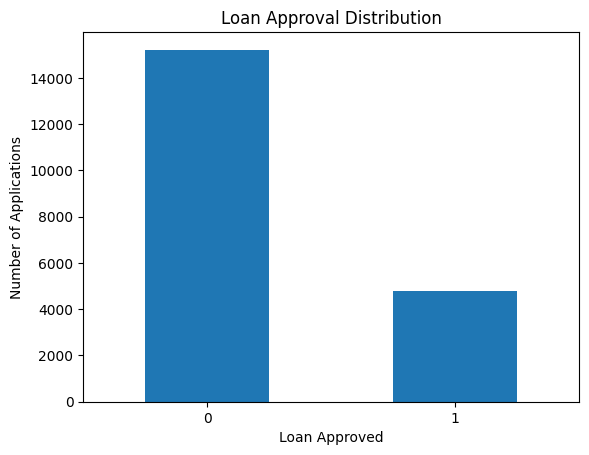

In [ ]:
# Visualizing the target variable
import matplotlib.pyplot as plt

data["loan_approved"].value_counts().plot(
    kind="bar",
    title="Loan Approval Distribution"
)

plt.xlabel("Loan Approved")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)
plt.show()

### **2. Understanding the Numerical Customer/Borrower Profile**

In [ ]:
# Numerical borrower characteristics
data[[
    "age",
    "annual_income",
    "credit_score",
    "number_of_dependents"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
age,20000.0,39.75260,11.622713,18.0,32.0,40.0,48.0,80.0
annual_income,20000.0,59161.47355,40350.845168,15000.0,31679.0,48566.0,74391.0,485341.0
credit_score,20000.0,571.61240,50.997358,343.0,540.0,578.0,609.0,712.0
number_of_dependents,20000.0,1.51730,1.386325,0.0,0.0,1.0,2.0,5.0


**Observation**
The borrower population is centered around middle-aged applicants, with an average age of approximately 40 years. The typical borrower earns around $48,566 annually based on the median income, has a credit score around 578, and has one dependent. Income shows substantial variation, with a small number of high-income borrowers extending the upper range considerably.

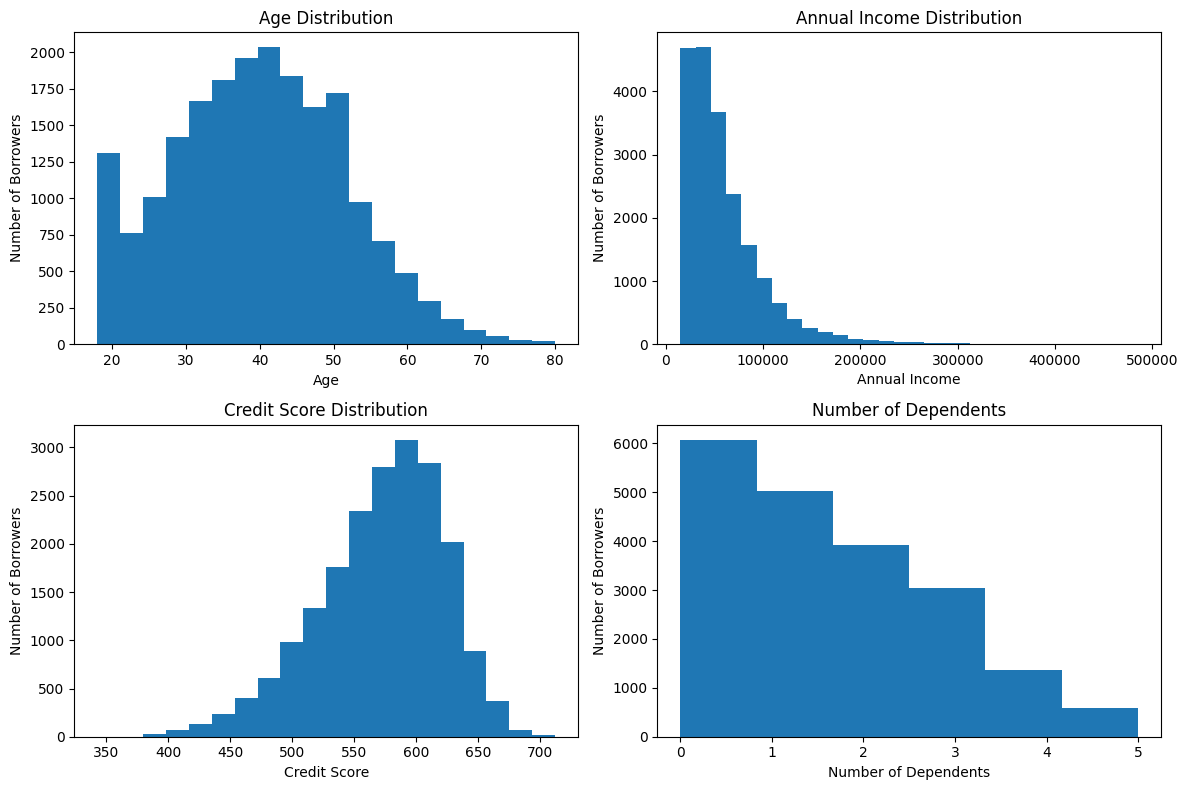

In [ ]:
# Visualizing the 4 numerical profile variables
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

data["age"].plot(kind="hist", bins=20, ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Number of Borrowers")

data["annual_income"].plot(kind="hist", bins=30, ax=axes[0, 1])
axes[0, 1].set_title("Annual Income Distribution")
axes[0, 1].set_xlabel("Annual Income")
axes[0, 1].set_ylabel("Number of Borrowers")

data["credit_score"].plot(kind="hist", bins=20, ax=axes[1, 0])
axes[1, 0].set_title("Credit Score Distribution")
axes[1, 0].set_xlabel("Credit Score")
axes[1, 0].set_ylabel("Number of Borrowers")

data["number_of_dependents"].plot(kind="hist", bins=6, ax=axes[1, 1])
axes[1, 1].set_title("Number of Dependents")
axes[1, 1].set_xlabel("Number of Dependents")
axes[1, 1].set_ylabel("Number of Borrowers")

plt.tight_layout()
plt.show()

Age is approximately symmetric, while annual income shows clear positive skewness due to a small number of high-income borrowers. Credit scores exhibit slight negative skewness, whereas the number of dependents is right-skewed, reflecting the concentration of borrowers with fewer dependents.

In [ ]:
# Fixing the skewness in annual income column
# Using logp1 to handle skewness since it will safely handle zero values if they appear

data["log_annual_income"] = np.log1p(data["annual_income"])

In [ ]:
print("Original skewness:", data["annual_income"].skew())
print("Log-transformed skewness:", data["log_annual_income"].skew())

Original skewness: 2.088947958524819
Log-transformed skewness: 0.15867184767171486


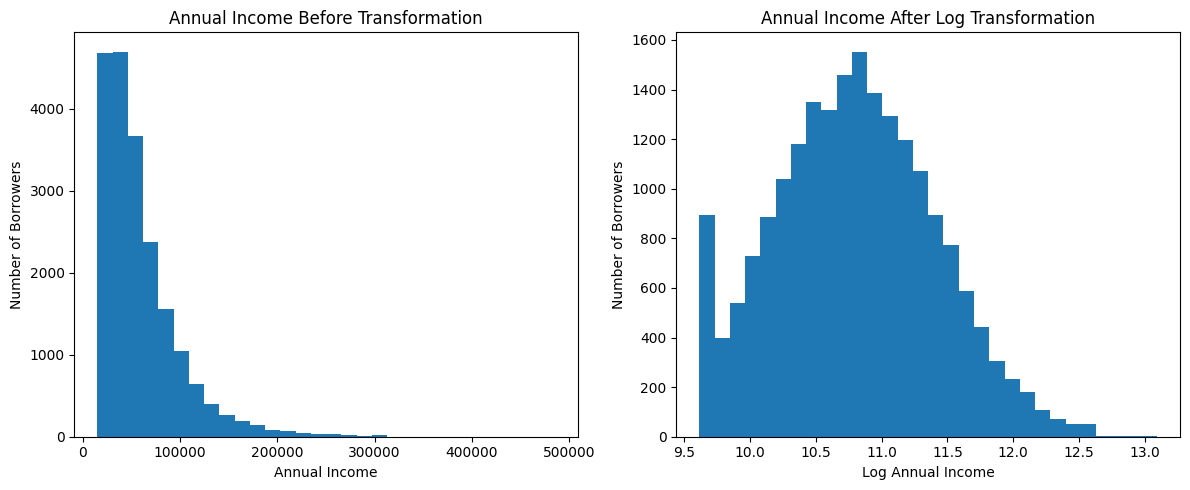

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original income
data["annual_income"].plot(
    kind="hist",
    bins=30,
    ax=axes[0]
)
axes[0].set_title("Annual Income Before Transformation")
axes[0].set_xlabel("Annual Income")
axes[0].set_ylabel("Number of Borrowers")

# Log-transformed income
data["log_annual_income"].plot(
    kind="hist",
    bins=30,
    ax=axes[1]
)
axes[1].set_title("Annual Income After Log Transformation")
axes[1].set_xlabel("Log Annual Income")
axes[1].set_ylabel("Number of Borrowers")

plt.tight_layout()
plt.show()

Annual income was strongly right-skewed in its original form (skewness = 2.09), largely due to a relatively small number of high-income borrowers. After log transformation, skewness decreased to 0.16, resulting in a more symmetric distribution with one primary concentration of borrowers.

#### **Examine the distribution of borrower ages**

In [ ]:
# Examine the distribution of borrower ages
data["age"].describe()

,age
count,20000.000000
mean,39.752600
std,11.622713
min,18.000000
25%,32.000000
50%,40.000000
75%,48.000000
max,80.000000


Borrower ages are centered around 40 years, with a mean of 39.75 and median of 40. The middle 50% of borrowers fall between 32 and 48 years, indicating that the dataset primarily represents working-age adults.

In [ ]:
# Divide borrower ages into 10-year intervals
# to see where most borrowers are concentrated.
age_bins = pd.cut(
    data["age"],
    bins=[18, 28, 38, 48, 58, 68, 78, 88],
    include_lowest=True
)

# Count borrowers in each age group
age_distribution = age_bins.value_counts().sort_index()

# Display the number of borrowers in each age group
print(age_distribution)

age
(17.999, 28.0]    3517
(28.0, 38.0]      5741
(38.0, 48.0]      6180
(48.0, 58.0]      3398
(58.0, 68.0]       997
(68.0, 78.0]       156
(78.0, 88.0]        11
Name: count, dtype: int64


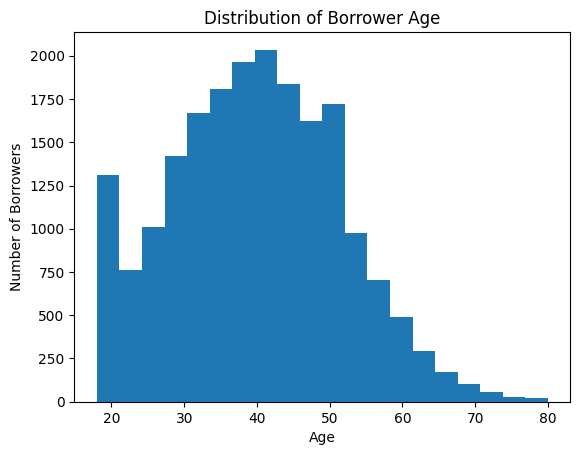

In [ ]:
# Visualize the distribution of borrower ages
data["age"].plot(
    kind="hist",
    bins=20,
    title="Distribution of Borrower Age"
)

# Label the axes so the chart is easy to interpret
plt.xlabel("Age")
plt.ylabel("Number of Borrowers")

# Display the chart
plt.show()

Borrowers are concentrated in the 29–48 age range, which accounts for approximately 59.6% of the dataset. The largest age group is 39–48 years (30.9%), followed by 29–38 years (28.7%). Borrowers aged 59 and above represent a relatively small share of the dataset.

### **Reviewing the distribution of borrower credit scores**

In [ ]:
# Review the distribution of borrower credit scores
data["credit_score"].describe()

,credit_score
count,20000.000000
mean,571.612400
std,50.997358
min,343.000000
25%,540.000000
50%,578.000000
75%,609.000000
max,712.000000


Borrower credit scores vary considerably, ranging from 343 to 712, with a median score of 578. The middle 50% of borrowers have scores between 540 and 609, while the mean of 571.61 is slightly below the median, indicating a modest concentration of lower credit scores.

In [ ]:
# Divide credit scores into meaningful ranges
# to examine where most borrowers are concentrated.
credit_score_bins = pd.cut(
    data["credit_score"],
    bins=[300, 400, 500, 550, 600, 650, 700, 750],
    right=True
)

# Count borrowers in each credit-score range
credit_score_distribution = (
    credit_score_bins
    .value_counts()
    .sort_index()
)

# Display the number of borrowers in each range
print(credit_score_distribution)

credit_score
(300, 400]      36
(400, 500]    1897
(500, 550]    4195
(550, 600]    7497
(600, 650]    5714
(650, 700]     655
(700, 750]       6
Name: count, dtype: int64


#### **Credit Score Profile Finding**
Credit scores are concentrated in the 551–650 range, which accounts for approximately 66.1% of borrowers. The largest group falls between 551 and 600 (37.5%), followed by 601–650 (28.6%). Extremely low and high credit scores are relatively uncommon in the dataset.

In [ ]:
# Review the distribution of the number of dependents
# among borrowers.
data["number_of_dependents"].value_counts().sort_index()

,count
number_of_dependents,
0,6074
1,5027
2,3916
3,3033
4,1362
5,588


Borrowers generally have relatively few dependents, with 55.5% reporting zero or one dependent and 75.1% reporting no more than two. Borrowers with four or five dependents account for only 9.7% of the dataset.

### **Categorical Borrower Profile**
#### **Employment status**

In [ ]:
# Counting borrowers in each employment-status category
# to understand the employment profile of the dataset.
employment_summary = pd.DataFrame({
    "Count": data["employment_status"].value_counts(),
    "Percentage": (
        data["employment_status"]
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
    )
})

print(employment_summary)

                   Count  Percentage
employment_status                   
Employed           17036        85.2
Self-Employed       1573         7.9
Unemployed          1391         7.0


he important observation is that 85.2% of borrowers are employed, while self-employed and unemployed borrowers each represent less than 10% of the dataset.

#### **Examining the Education Level**

In [ ]:
# Count borrowers in each education-level category,
# including the "Unknown" category created during missing-value handling.
# Summarize education level using both counts and percentages
education_summary = pd.DataFrame({
    "Count": data["education_level"].value_counts(),
    "Percentage": (
        data["education_level"]
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
    )
})

# Display the summary
print(education_summary)

                 Count  Percentage
education_level                   
Bachelor          5804        29.0
High School       5592        28.0
Associate         3850        19.2
Master            2933        14.7
Doctorate          920         4.6
Unknown            901         4.5


Borrowers have varied educational backgrounds, with Bachelor's degree holders representing the largest group (29.0%), closely followed by high school graduates (28.0%). Together, these groups account for 57.0% of borrowers. Missing education information represents 4.5% of the dataset and was retained as an explicit "Unknown" category.

#### **Home Ownership Category**

In [ ]:
# Counting borrowers in each home-ownership category
home_ownership_counts = data["home_ownership_status"].value_counts()

# Calculating the percentage of borrowers in each category
home_ownership_percentages = (
    data["home_ownership_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

# Combining counts and percentages into one summary table
home_ownership_summary = pd.DataFrame({
    "Count": home_ownership_counts,
    "Percentage": home_ownership_percentages
})

# Display the summary
print(home_ownership_summary)

                       Count  Percentage
home_ownership_status                   
Mortgage                7939        39.7
Rent                    6087        30.4
Own                     3938        19.7
Other                   2036        10.2


**Home ownership status:**

Borrowers are predominantly in the mortgage and rental categories, accounting for 39.7% and 30.4% of the dataset respectively. Borrowers who own their homes outright represent 19.7%, while 10.2% fall under other housing arrangements.

### **Borrower Profile Summary**
Borrowers are primarily working-age adults, with approximately 59.6% between 29 and 48 years old.

The dataset is predominantly composed of employed borrowers (85.2%), while Bachelor's degree holders (29.0%) and high school graduates (28.0%) make up the largest education groups.

Credit scores are concentrated between 551 and 650, accounting for approximately 66.1% of borrowers. Most borrowers have relatively few dependents, with 75.1% reporting no more than two.

Housing arrangements are largely centered around mortgages (39.7%) and renting (30.4%). Annual income is right-skewed, with a small number of higher-income borrowers extending the upper range of the distribution.

### **3. Loan & Financial Profile**
In this section, we are trying to answer the question, what does the borrower's loans and financial obligations look like?

We will break it into;

**a.Loan characteristics**
* loan_amount
* loan_duration
* monthly_loan_payment
* interest_rate

**b. Debt & financial position**
* monthly_debt_payments
* debt_to_income_ratio
* total_debt_to_income_ratio
* total_liabilities
* net_worth

**c. Financial resources**
* annual_income
* savings_account_balance
* checking_account_balance
* total_assets

#### **a. Loan Characteristics**

In [ ]:
# Examine the basic statistics of key loan characteristics
loan_features = [
    "loan_amount",
    "loan_duration",
    "monthly_loan_payment",
    "interest_rate"
]

data[loan_features].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,184732.000000
loan_duration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,120.000000
monthly_loan_payment,20000.0,911.607052,674.583473,97.030193,493.763700,728.511452,1112.770759,10892.629520
interest_rate,20000.0,0.239110,0.042205,0.113310,0.209142,0.235390,0.265532,0.446787


**Loan characteristics:** The average loan amount was approximately 24, 883, with half of the loans falling between $15,575 - $30,835 dollars. Loan durations were typically between 36 and 72 months, with a median of 48 months.

 The median monthly loan payment was approximately $729, while the median interest rate was 23.5%. Loan amount and monthly payment showed noticeable right-skew, driven by a smaller number of higher-value loans and larger payment amounts.

In [ ]:
# Understanding loan amount distribution using percentage brands
# Divide loan amounts into practical ranges
loan_amount_bins = pd.cut(
    data["loan_amount"],
    bins=[0, 10000, 20000, 30000, 50000, 100000, float("inf")],
    labels=[
        "Under 10K",
        "10K–20K",
        "20K–30K",
        "30K–50K",
        "50K–100K",
        "100K+"
    ]
)

# Calculate counts and percentages for each loan range
loan_amount_summary = pd.DataFrame({
    "Count": loan_amount_bins.value_counts().sort_index(),
    "Percentage": (
        loan_amount_bins
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(1)
    )
})

print(loan_amount_summary)

             Count  Percentage
loan_amount                   
Under 10K     1175         5.9
10K–20K       7418        37.1
20K–30K       6057        30.3
30K–50K       4309        21.5
50K–100K      1008         5.0
100K+           33         0.2


Loan amount: Loan amounts are concentrated between $10,000 - $30,000 dollars, accounting for 67.4% of applications. The largest group falls within the $10,000–$20,000 range (37.1%), followed by $20,000–$30,000 (30.3%). Loans above $100,000 are rare, representing only 0.2% of applications, indicating that the high maximum loan amount is driven by a small number of observations.

In [ ]:
# Checking the loan duration
# Divide loan durations into practical ranges in months
loan_duration_bins = pd.cut(
    data["loan_duration"],
    bins=[0, 24, 36, 48, 60, 72, 120],
    labels=[
        "Up to 24 months",
        "25–36 months",
        "37–48 months",
        "49–60 months",
        "61–72 months",
        "73–120 months"
    ]
)

# Calculate counts and percentages for each duration range
loan_duration_summary = pd.DataFrame({
    "Count": loan_duration_bins.value_counts().sort_index(),
    "Percentage": (
        loan_duration_bins
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(1)
    )
})

print(loan_duration_summary)

                 Count  Percentage
loan_duration                     
Up to 24 months   2931        14.7
25–36 months      3971        19.9
37–48 months      3991        20.0
49–60 months      3982        19.9
61–72 months      2046        10.2
73–120 months     3079        15.4


**Loan duration:** Loan durations are relatively evenly distributed across the main ranges, with 25–60 month loans accounting for 59.8% of applications. The largest individual group is 37–48 months (20.0%), while loans lasting 73–120 months account for 15.4%. This indicates that borrowers in the dataset use a relatively broad range of repayment periods.

In [ ]:
# Understanding loan montly payments
# Divide monthly loan payments into practical ranges
monthly_payment_bins = pd.cut(
    data["monthly_loan_payment"],
    bins=[0, 500, 750, 1000, 1500, 2500, float("inf")],
    labels=[
        "Under $500",
        "$500–$750",
        "$750–$1,000",
        "$1,000–$1,500",
        "$1,500–$2,500",
        "$2,500+"
    ]
)

# Calculate counts and percentages for each payment range
monthly_payment_summary = pd.DataFrame({
    "Count": monthly_payment_bins.value_counts().sort_index(),
    "Percentage": (
        monthly_payment_bins
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(1)
    )
})

print(monthly_payment_summary)

                      Count  Percentage
monthly_loan_payment                   
Under $500             5139        25.7
$500–$750              5212        26.1
$750–$1,000            3529        17.6
$1,000–$1,500          3572        17.9
$1,500–$2,500          1910         9.6
$2,500+                 638         3.2


**Monthly loan payments:** Monthly payments are concentrated at the lower end of the distribution, with 51.8% of borrowers paying less than $750 per month. The largest group falls between $500 and $750 (26.1%), followed closely by borrowers paying under $500 (25.7%). Payments above $2,500 are relatively uncommon, representing 3.2% of borrowers.

In [ ]:
# Checking the interest rate distribution as part of loan characteristics
# Convert interest rates from decimal values to percentages
interest_rate_pct = data["interest_rate"] * 100

# Divide interest rates into practical percentage ranges
interest_rate_bins = pd.cut(
    interest_rate_pct,
    bins=[0, 15, 20, 25, 30, 35, 50],
    labels=[
        "Below 15%",
        "15%–20%",
        "20%–25%",
        "25%–30%",
        "30%–35%",
        "Above 35%"
    ]
)

# Calculate counts and percentages for each interest-rate range
interest_rate_summary = pd.DataFrame({
    "Count": interest_rate_bins.value_counts().sort_index(),
    "Percentage": (
        interest_rate_bins
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(1)
    )
})

print(interest_rate_summary)

               Count  Percentage
interest_rate                   
Below 15%         95         0.5
15%–20%         3429        17.1
20%–25%         9068        45.3
25%–30%         5709        28.5
30%–35%         1479         7.4
Above 35%        220         1.1


**Interest rates:**

 Interest rates are concentrated between 20% and 30%, which accounts for 73.8% of borrowers. The largest group falls within the 20%–25% range (45.3%), followed by 25%–30% (28.5%). Rates below 15% and above 35% are relatively uncommon, representing 0.5% and 1.1% of borrowers respectively.

### **b. Understanding Customer's Debt and Financial Position**

Here we'll investigate:

* monthly_debt_payments
* debt_to_income_ratio
* total_debt_to_income_ratio
* total_liabilities
* net_worth

In [ ]:
# Understanding customer's monthly debt payment
# Examine the basic statistics of key debt and financial-position variables
debt_features = [
    "monthly_debt_payments",
    "debt_to_income_ratio",
    "total_debt_to_income_ratio",
    "total_liabilities",
    "net_worth"
]

data[debt_features].describe().T

,count,mean,std,min,25%,50%,75%,max
monthly_debt_payments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
debt_to_income_ratio,20000.0,0.285735,0.160211,0.001720,0.161035,0.264454,0.390327,9.022527e-01
total_debt_to_income_ratio,20000.0,0.402182,0.338924,0.016043,0.179693,0.302711,0.509214,4.647657e+00
total_liabilities,20000.0,36252.412750,47251.510913,372.000000,11196.750000,22203.000000,43146.500000,1.417302e+06
net_worth,20000.0,72294.318850,117920.021444,1000.000000,8734.750000,32855.500000,88825.500000,2.603208e+06


In [ ]:
# Calculating total debt to income ratio
# Convert total debt-to-income ratio to percentages
total_dti_pct = data["total_debt_to_income_ratio"] * 100

# Divide total DTI into practical ranges
total_dti_bins = pd.cut(
    total_dti_pct,
    bins=[0, 20, 30, 40, 50, 60, 100, float("inf")],
    labels=[
        "Below 20%",
        "20%–30%",
        "30%–40%",
        "40%–50%",
        "50%–60%",
        "60%–100%",
        "Above 100%"
    ]
)

# Calculate counts and percentages for each DTI range
total_dti_summary = pd.DataFrame({
    "Count": total_dti_bins.value_counts().sort_index(),
    "Percentage": (
        total_dti_bins
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(1)
    )
})

print(total_dti_summary)

                            Count  Percentage
total_debt_to_income_ratio                   
Below 20%                    5900        29.5
20%–30%                      4017        20.1
30%–40%                      2829        14.1
40%–50%                      2091        10.5
50%–60%                      1414         7.1
60%–100%                     2582        12.9
Above 100%                   1167         5.8


Total debt-to-income ratios are concentrated below 60%, with 64.0% of borrowers falling below 40%. However, 18.7% of borrowers have ratios above 60%, including 5.8% with ratios exceeding 100%. This indicates a substantial high-debt segment and explains why the variable has a long upper tail.

In [ ]:
# Understanding total liabilities of customers
# Divide total liabilities into practical financial ranges
liability_bins = pd.cut(
    data["total_liabilities"],
    bins=[0, 10000, 25000, 50000, 100000, 250000, 500000, float("inf")],
    labels=[
        "Below $10K",
        "$10K–$25K",
        "$25K–$50K",
        "$50K–$100K",
        "$100K–$250K",
        "$250K–$500K",
        "Above $500K"
    ]
)

# Calculate counts and percentages for each liability range
liability_summary = pd.DataFrame({
    "Count": liability_bins.value_counts().sort_index(),
    "Percentage": (
        liability_bins
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(1)
    )
})

print(liability_summary)

                   Count  Percentage
total_liabilities                   
Below $10K          4293        21.5
$10K–$25K           6658        33.3
$25K–$50K           4947        24.7
$50K–$100K          2841        14.2
$100K–$250K         1100         5.5
$250K–$500K          143         0.7
Above $500K           18         0.1


Total liabilities are concentrated below $50,000, with 79.5% of borrowers falling within this range. Only 0.8% of borrowers have liabilities above $250,000, indicating that the extreme maximum of $1.42 million is driven by a small number of high-liability observations.

In [ ]:
# Checking the networth output of customers
# Divide net worth into practical financial ranges
net_worth_bins = pd.cut(
    data["net_worth"],
    bins=[0, 10000, 25000, 50000, 100000, 250000, 500000, float("inf")],
    labels=[
        "Below $10K",
        "$10K–$25K",
        "$25K–$50K",
        "$50K–$100K",
        "$100K–$250K",
        "$250K–$500K",
        "Above $500K"
    ]
)

# Calculate counts and percentages for each net worth range
net_worth_summary = pd.DataFrame({
    "Count": net_worth_bins.value_counts().sort_index(),
    "Percentage": (
        net_worth_bins
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(1)
    )
})

print(net_worth_summary)

             Count  Percentage
net_worth                     
Below $10K    5874        29.4
$10K–$25K     2989        14.9
$25K–$50K     3129        15.6
$50K–$100K    3641        18.2
$100K–$250K   3221        16.1
$250K–$500K    906         4.5
Above $500K    240         1.2


**Key Findings** Net worth varies considerably across borrowers, with 59.9% reporting net worth below $50,000 and 78.1% below $100,000. However, 5.7% of borrowers have net worth above $250,000, including 1.2% above $500,000, indicating a relatively small but meaningful higher-net-worth segment.

### **c. We will investigate the financial resources of our customers**
We will analyze customers' annual income, savings account balances, checking account balances, and total assets to understand their overall financial resources and the distribution of available funds across borrowers.

In [ ]:
# Examine the basic statistics of borrowers' savings account balances
data["savings_account_balance"].describe()

,savings_account_balance
count,20000.000000
mean,4893.073900
std,6541.095515
min,73.000000
25%,1576.000000
50%,2988.500000
75%,5701.000000
max,200089.000000


In [ ]:
# Creating practical saving ranges
# Divide savings balances into practical financial ranges
savings_bins = pd.cut(
    data["savings_account_balance"],
    bins=[0, 1000, 2500, 5000, 10000, 25000, 50000, float("inf")],
    labels=[
        "Below $1K",
        "$1K–$2.5K",
        "$2.5K–$5K",
        "$5K–$10K",
        "$10K–$25K",
        "$25K–$50K",
        "Above $50K"
    ]
)

# Calculate counts and percentages for each savings range
savings_summary = pd.DataFrame({
    "Count": savings_bins.value_counts().sort_index(),
    "Percentage": (
        savings_bins
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(1)
    )
})

print(savings_summary)

                         Count  Percentage
savings_account_balance                   
Below $1K                 2660        13.3
$1K–$2.5K                 5622        28.1
$2.5K–$5K                 5853        29.3
$5K–$10K                  3698        18.5
$10K–$25K                 1840         9.2
$25K–$50K                  262         1.3
Above $50K                  65         0.3


Savings balances are concentrated at relatively modest levels, with 70.7% of borrowers holding less than $5,000 and 89.2% holding less than $10,000.
Only 1.6% of borrowers have savings above $25,000, indicating that the extreme maximum of $200,089 is driven by a very small number of high-balance observations.

In [ ]:
# checking the account balance
# Examine the basic statistics of borrowers' checking account balances
data["checking_account_balance"].describe()

,checking_account_balance
count,20000.000000
mean,1782.555100
std,2245.378812
min,24.000000
25%,551.000000
50%,1116.000000
75%,2126.000000
max,52572.000000


In [ ]:
# Checking account balance changes
# Divide checking account balances into practical financial ranges
checking_bins = pd.cut(
    data["checking_account_balance"],
    bins=[0, 500, 1000, 2500, 5000, 10000, 25000, float("inf")],
    labels=[
        "Below $500",
        "$500–$1K",
        "$1K–$2.5K",
        "$2.5K–$5K",
        "$5K–$10K",
        "$10K–$25K",
        "Above $25K"
    ]
)

# Calculate counts and percentages for each checking balance range
checking_summary = pd.DataFrame({
    "Count": checking_bins.value_counts().sort_index(),
    "Percentage": (
        checking_bins
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(1)
    )
})

print(checking_summary)

                          Count  Percentage
checking_account_balance                   
Below $500                 4380        21.9
$500–$1K                   4791        24.0
$1K–$2.5K                  6801        34.0
$2.5K–$5K                  2782        13.9
$5K–$10K                    988         4.9
$10K–$25K                   245         1.2
Above $25K                   13         0.1


#### **Account Balance Findings**
Checking account balances are concentrated at relatively low levels, with 79.9% of borrowers holding less than $2,500 and 93.8% holding less than $5,000. Only 1.3% have balances above $10,000, indicating that the maximum value of $52,572 is driven by a very small number of high-balance observations.

In [ ]:
# Checking the total assets of the borrower
# Examine the basic statistics of borrowers' total assets
data["total_assets"].describe()

,total_assets
count,2.000000e+04
mean,9.696440e+04
std,1.207999e+05
min,2.098000e+03
25%,3.118025e+04
50%,6.069900e+04
75%,1.174052e+05
max,2.619627e+06


The mean is considerably higher than the median, indicating a right-skewed distribution. A relatively small group of borrowers with very high asset values is pulling the average upward.

Also, notice something interesting: the median total assets ($60.7K) is substantially higher than the median savings and checking balances. That's expected because total assets can include things such as property and other valuable holdings, not just cash balances.

The maximum of $2.62M is very high relative to the 75th percentile, so we should investigate how many borrowers actually fall into these higher asset ranges before deciding how unusual it is.

In [ ]:
# creating the asset ranges
# Divide total assets into practical financial ranges
asset_bins = pd.cut(
    data["total_assets"],
    bins=[0, 25000, 50000, 100000, 250000, 500000, 1000000, float("inf")],
    labels=[
        "Below $25K",
        "$25K–$50K",
        "$50K–$100K",
        "$100K–$250K",
        "$250K–$500K",
        "$500K–$1M",
        "Above $1M"
    ]
)

# Calculate counts and percentages for each asset range
asset_summary = pd.DataFrame({
    "Count": asset_bins.value_counts().sort_index(),
    "Percentage": (
        asset_bins
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(1)
    )
})

print(asset_summary)

              Count  Percentage
total_assets                   
Below $25K     3660        18.3
$25K–$50K      4789        23.9
$50K–$100K     5456        27.3
$100K–$250K    4689        23.4
$250K–$500K    1124         5.6
$500K–$1M       242         1.2
Above $1M        40         0.2


What the distribution tells us
* 18.3% have assets below 25K.
* 42.2% have assets below 50K.
* 69.5% have assets below 100K.
* 92.9% have assets below 250K.
* 6.8% have assets above 250K.
* Only 1.4% have assets above 500K.
* and just 0.2% have assets above $1M.

So the $2.62M maximum is an extreme upper-tail value, but there is still a meaningful group of borrowers with assets above 250K dollars.

### **Overall Finding**

Financial resources vary considerably across borrowers, with cash balances concentrated at relatively modest levels. 70.7% of borrowers have savings below $5,000, while 79.9% have checking account balances below $2,500. Total assets are more broadly distributed, with 69.5% of borrowers holding less than $100,000 and 92.9% below $250,000.

The financial-resource variables also show right-skewed distributions, with a relatively small number of borrowers having substantially higher balances and asset levels. These patterns highlight considerable variation in borrowers' financial resources, which can be examined further in relation to loan approval and risk outcomes.

In [ ]:
# detecting outliers in the dataset
for col in num_features:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = data[
        (data[col] < lower) |
        (data[col] > upper)
    ]

    print(col,":",len(outliers),"outliers")

age : 64 outliers
annualincome : 947 outliers
creditscore : 242 outliers
experience : 75 outliers
loanamount : 746 outliers
loanduration : 0 outliers
numberofdependents : 0 outliers
monthlydebtpayments : 744 outliers
creditcardutilizationrate : 130 outliers
numberofopencreditlines : 249 outliers
numberofcreditinquiries : 16 outliers
debttoincomeratio : 143 outliers
previousloandefaults : 2001 outliers
paymenthistory : 241 outliers
lengthofcredithistory : 0 outliers
savingsaccountbalance : 1547 outliers
checkingaccountbalance : 1522 outliers
totalassets : 1442 outliers
totalliabilities : 1533 outliers
monthlyincome : 925 outliers
utilitybillspaymenthistory : 294 outliers
jobtenure : 251 outliers
networth : 1564 outliers
baseinterestrate : 219 outliers
interestrate : 222 outliers
monthlyloanpayment : 1089 outliers
totaldebttoincomeratio : 1152 outliers
riskscore : 94 outliers


**Outlier Analysis**

The interquartile range (IQR) method was used to identify potential outliers across the numerical features. Several variables, including Previous Loan Defaults (2,001 outliers), Net Worth (1,564), Total Liabilities (1,533), Checking Account Balance (1,522), Savings Account Balance (1,547), and Monthly Loan Payment (1,089), contained a relatively large number of observations outside the typical range.

In contrast, variables such as Loan Duration, Number of Dependents, and Length of Credit History contained no detected outliers, suggesting that these features have more stable distributions.

The presence of outliers is expected in financial datasets because applicants naturally vary in income, assets, liabilities, loan amounts, and credit histories. These observations may represent genuine high-value customers or applicants with unusually high debt rather than data entry errors.

Since the final model is a Random Forest classifier, no outlier removal was performed. Random Forest models partition the data using decision trees and are generally less sensitive to extreme values than distance-based algorithms such as K-Nearest Neighbors or linear models. Removing these observations could have eliminated valuable information about legitimate high-risk or high-income applicants and potentially reduced the model's predictive performance.

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



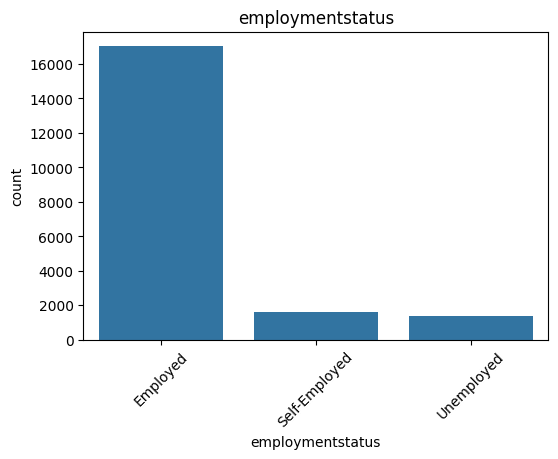

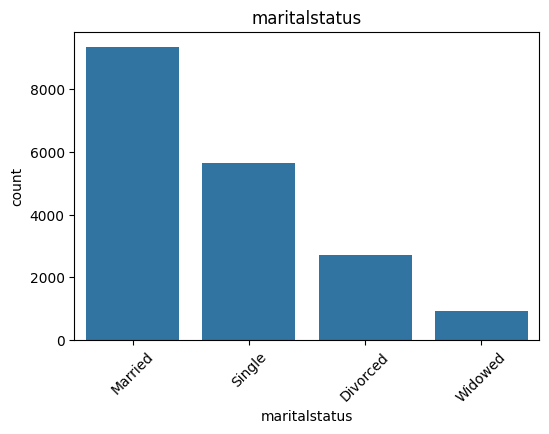

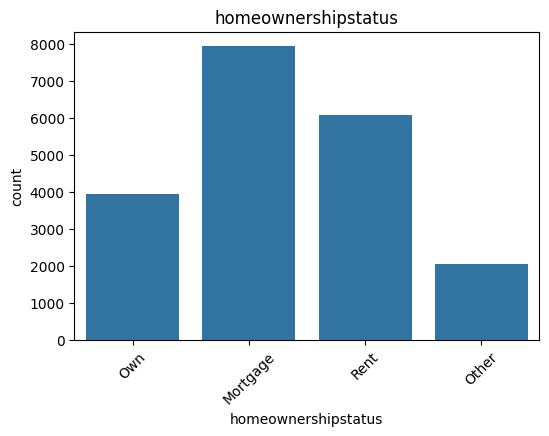

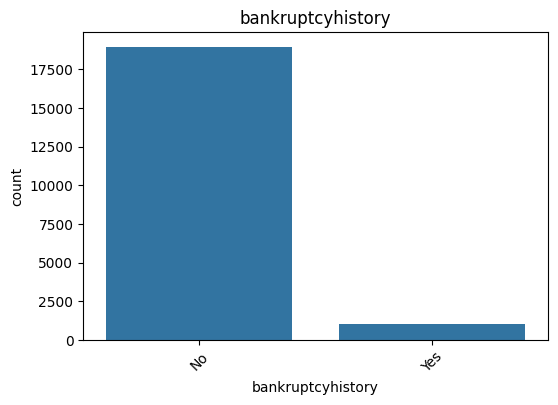

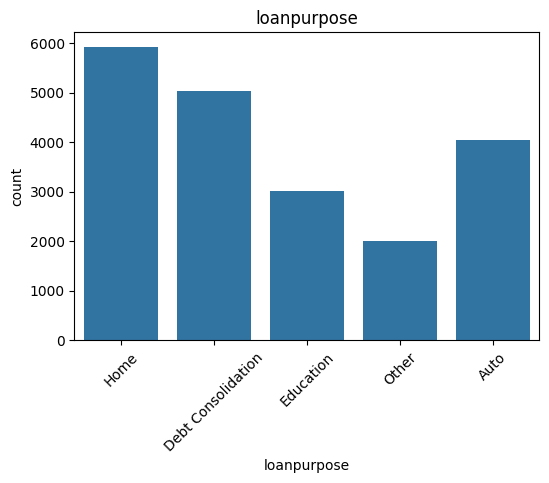

In [ ]:
# investigating the distribution of numerical variables
for col in cat_features:

    plt.figure(figsize=(6,4))

    sns.countplot(
        x=col,
        data=data
    )

    plt.xticks(rotation=45)

    plt.title(col)

    plt.show()

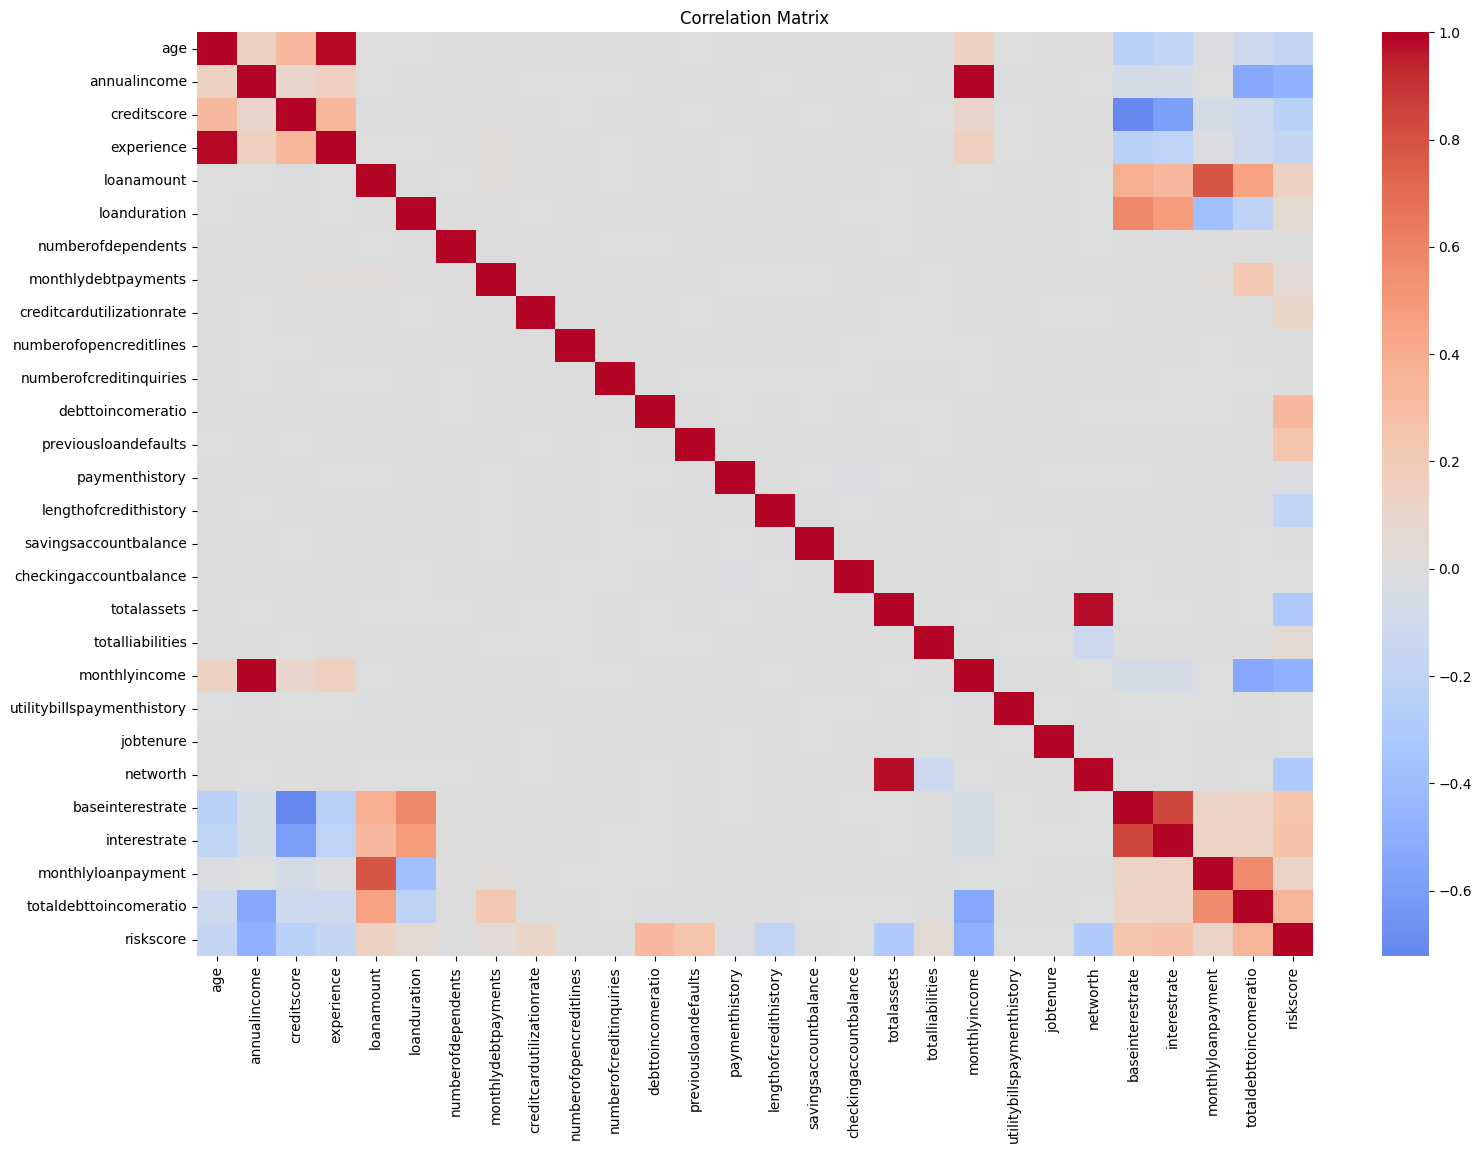

In [ ]:
# investigating relationships between features
#correlation matrix
corr = data[num_features].corr()

plt.figure(figsize=(18,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

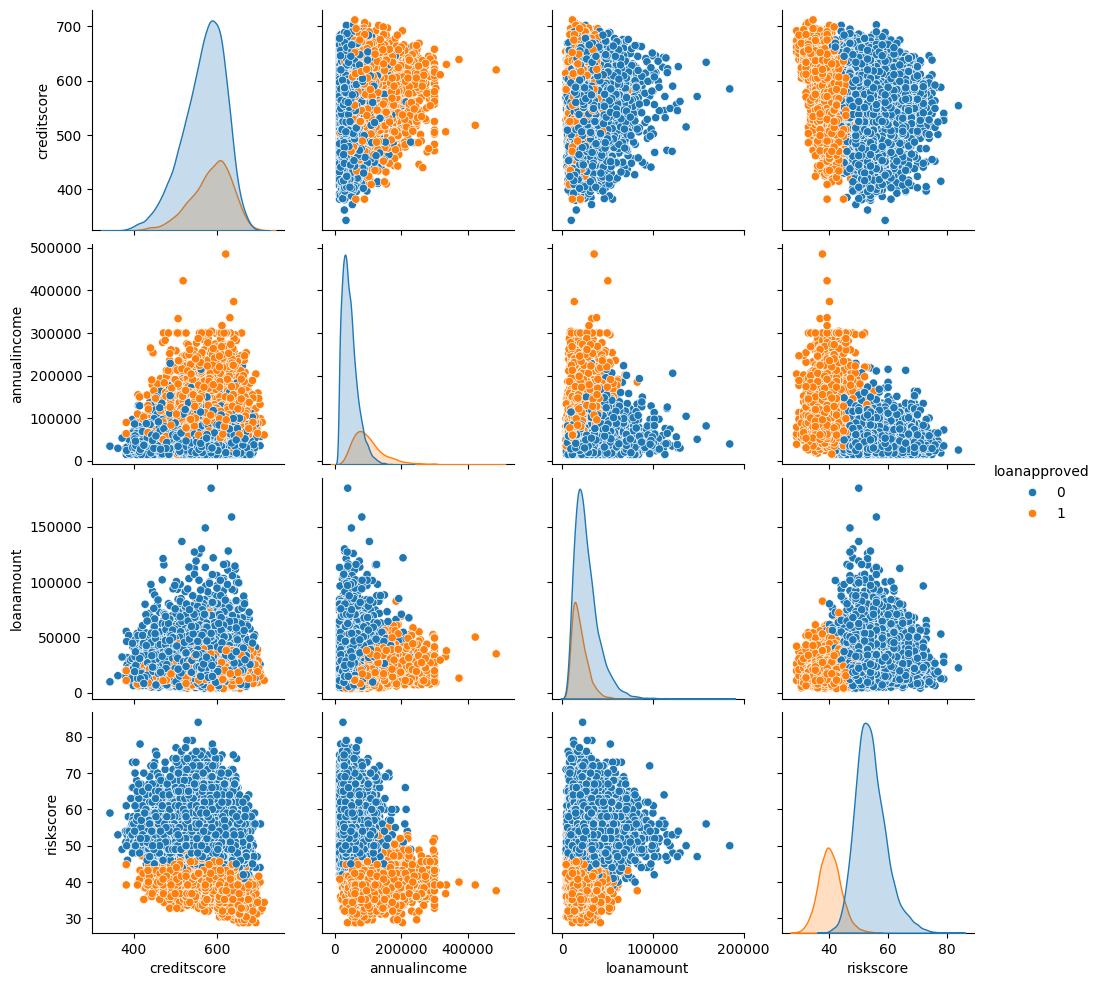

In [ ]:
sns.pairplot(
    data[
        [
            "creditscore",
            "annualincome",
            "loanamount",
            "riskscore",
            "loanapproved"
        ]
    ],
    hue="loanapproved"
)

plt.show()

In [ ]:
#Feature understanding
num_features


['age',
 'annualincome',
 'creditscore',
 'experience',
 'loanamount',
 'loanduration',
 'numberofdependents',
 'monthlydebtpayments',
 'creditcardutilizationrate',
 'numberofopencreditlines',
 'numberofcreditinquiries',
 'debttoincomeratio',
 'previousloandefaults',
 'paymenthistory',
 'lengthofcredithistory',
 'savingsaccountbalance',
 'checkingaccountbalance',
 'totalassets',
 'totalliabilities',
 'monthlyincome',
 'utilitybillspaymenthistory',
 'jobtenure',
 'networth',
 'baseinterestrate',
 'interestrate',
 'monthlyloanpayment',
 'totaldebttoincomeratio',
 'riskscore']

In [ ]:
cat_features


['employmentstatus',
 'maritalstatus',
 'homeownershipstatus',
 'bankruptcyhistory',
 'loanpurpose']

In [ ]:

ordinal_features

['educationlevel']

In [ ]:
#Debt to income categories

data["DTI_Category"] = pd.cut(
    data["debttoincomeratio"],
    bins=[0,20,35,50,100],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

In [ ]:
#Income group categories

data["Income_Group"] = pd.qcut(
    data["monthlyincome"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [ ]:
#Credit score categories

data["Credit_Category"] = pd.cut(
    data["creditscore"],
    bins=[300,580,670,740,850],
    labels=[
        "Poor",
        "Fair",
        "Good",
        "Excellent"
    ]
)

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune”


**data splitting**

In [ ]:
#seperate target and features

X = data.drop("loanapproved", axis=1)
y = data["loanapproved"]

**Identify feature types**

In [ ]:
cat_columns = [
    "employmentstatus",
    "educationlevel",
    "maritalstatus",
    "homeownershipstatus",
    "bankruptcyhistory",
    "loanpurpose"
]

num_columns = [
    col for col in X.columns
    if col not in cat_columns
]

In [ ]:
#seperate train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.30, stratify=y, random_state=42)

**pipeline for processing categorical and numerical columns**

In [ ]:
#handling categorical columns
cat_pipeline = Pipeline([

    ("cat_imputation", SimpleImputer(fill_value='missing',strategy='constant')),

    ("one_hot_encodeing", OneHotEncoder(sparse_output=False, drop="first", dtype='int', handle_unknown="ignore"))
])

In [ ]:
#handling numeric columns
num_pipeline = Pipeline([

    ("num_imputation", SimpleImputer(strategy= "median")),
    ("feature_scaling", StandardScaler())
])

**Separating numerical and categorical columns**

In [ ]:
#cat columns

cat_colnm = X.select_dtypes(include=["object", "category"]).columns.tolist()

#num columns
num_colnm = X.select_dtypes(include=np.number).columns.tolist()

**Combine all the categorical and numerical columns into one**

In [ ]:
preprocesser  = ColumnTransformer([

    ("category", cat_pipeline, cat_colnm),
    ("numeric", num_pipeline, num_colnm)
])

**Splitting the dataset into training and test set**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

**Creating the modeling pipeline**

In [ ]:
LA_pipe = Pipeline([

    ("preprocessing", preprocesser),
    ("estimator", RandomForestClassifier(random_state=42))
])

**Train the model**

In [ ]:
LA_pipe.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('category',
                                                  Pipeline(steps=[('cat_imputation',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('one_hot_encodeing',
                                                                   OneHotEncoder(drop='first',
                                                                                 dtype='int',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['employmentstatus',
                                                   'educationlevel',
                                                   'maritalstatus',
                                                   'homeownershipstatus'...
                                                   'previousloandefaults',
                                                   'paymenthistory',
                                                   'lengthofcredithistory',
                                                   'savingsaccountbalance',
                                                   'checkingaccountbalance',
                                                   'totalassets',
                                                   'totalliabilities',
                                                   'monthlyincome',
                                                   'utilitybillspaymenthistory',
                                                   'jobtenure', 'networth',
                                                   'baseinterestrate',
                                                   'interestrate',
                                                   'monthlyloanpayment',
                                                   'totaldebttoincomeratio',
                                                   'riskscore'])])),
                ('estimator', RandomForestClassifier(random_state=42))])

**Making model predictions**

In [ ]:
y_pred = LA_pipe.predict(X_test)

**Evaluate the model using train-test-split**

In [ ]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Precision:",
    precision_score(y_test, y_pred)
)

print(
    "Recall:",
    recall_score(y_test, y_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred)
)

print()

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.98925
Precision: 0.9840933191940615
Recall: 0.9707112970711297
F1 Score: 0.9773565034228542

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3044
           1       0.98      0.97      0.98       956

    accuracy                           0.99      4000
   macro avg       0.99      0.98      0.99      4000
weighted avg       0.99      0.99      0.99      4000



## **Cross Validate**

In [ ]:
cv_scores = cross_val_score(
    LA_pipe,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("f1 Scores:", cv_scores)

print()

print("Mean f1:", cv_scores.mean())

f1 Scores: [0.98145695 0.97293729 0.96965699 0.97769029 0.97841727]

Mean f1: 0.9760317588714301


The model achieved F1-scores ranging from 0.9697 to 0.9815 across the five folds, with a mean F1-score of 0.9760. The small variation in scores indicates that the model performs consistently across different subsets of the training data. Furthermore, the mean cross-validation F1-score is very close to the final test F1-score of 0.9774, suggesting that the model generalizes well to unseen data and exhibits minimal signs of overfitting.

## **Tuning hyperparameters using GridSearchCV**

In [ ]:
param_grid = {

    "estimator__n_estimators": [
        200
    ],

    "estimator__max_depth": [
        None,
        20
    ],

    "estimator__min_samples_split": [
        2,
        5
    ],

    "estimator__min_samples_leaf": [
        1,
        2
    ],

    "estimator__max_features": [
        "sqrt",
        "log2"
    ]
}

**Performing the Grid Search**

In [ ]:
grid_search = GridSearchCV(

    estimator=LA_pipe,

    param_grid=param_grid,

    scoring="f1",

    cv=5,

    n_jobs=-1,

    verbose=2,

    refit=True

)

In [ ]:
#Running the tuning
grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('category',
                                                                         Pipeline(steps=[('cat_imputation',
                                                                                          SimpleImputer(fill_value='missing',
                                                                                                        strategy='constant')),
                                                                                         ('one_hot_encodeing',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        dtype='int',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['employmentstatus',
                                                                          'educationlevel',
                                                                          'maritals...
                                                                          'interestrate',
                                                                          'monthlyloanpayment',
                                                                          'totaldebttoincomeratio',
                                                                          'riskscore'])])),
                                       ('estimator',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'estimator__max_depth': [None, 20],
                         'estimator__max_features': ['sqrt', 'log2'],
                         'estimator__min_samples_leaf': [1, 2],
                         'estimator__min_samples_split': [2, 5],
                         'estimator__n_estimators': [200]},
             scoring='f1', verbose=2)

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Best Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'estimator__max_depth': 20, 'estimator__max_features': 'sqrt', 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 200}
Best Cross-Validation F1 Score:
0.9774817199145938


**Hyperparameter Tuning:** GridSearchCV was used with 5-fold cross-validation to identify the optimal Random Forest hyperparameters. The F1-score was selected as the optimization metric because it balances precision and recall, which is important for credit risk prediction. The search evaluated combinations of the number of trees, maximum tree depth, and minimum samples required for splitting to determine the configuration that produced the best cross-validation performance.

**Checking for the best parameters**

In [ ]:
print(
    "Best Parameters:"
)

print(
    grid_search.best_params_
)

print()

print(
    "Best Cross Validation F1:"
)

print(
    grid_search.best_score_
)

Best Parameters:
{'estimator__max_depth': 20, 'estimator__max_features': 'sqrt', 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 200}

Best Cross Validation F1:
0.9774817199145938


In [ ]:
# best model
best_model = grid_search.best_estimator_

In [ ]:
# final predictions
best_predictions = best_model.predict(X_test)

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

In [ ]:
# Make predictions using the best model
y_pred = best_model.predict(X_test)

In [ ]:
# evaluating the performance of the test set score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.98925
Precision: 0.9840933191940615
Recall: 0.9707112970711297
F1 Score: 0.9773565034228542

Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3044
           1       0.98      0.97      0.98       956

    accuracy                           0.99      4000
   macro avg       0.99      0.98      0.99      4000
weighted avg       0.99      0.99      0.99      4000



### **Confusion Matrix**

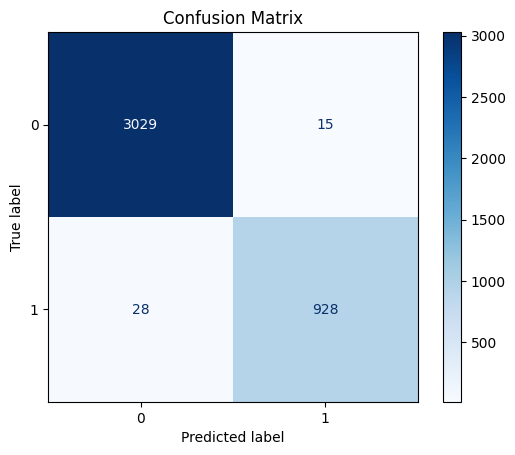

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

### **The ROC Curve and ROC-AUC**

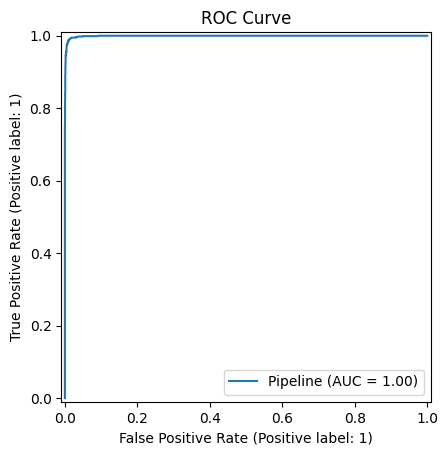

ROC-AUC Score: 0.9992610128162129


In [ ]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

# ROC-AUC Score
y_prob = best_model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

**Interpreting the ROC-AUC curve results**\
The Random Forest classifier achieved a ROC-AUC score of 0.9993, indicating an exceptional ability to distinguish between approved and non-approved loan applications across all classification thresholds. Since the ROC-AUC score ranges from 0.5 (no discrimination) to 1.0 (perfect discrimination), a value of 0.9993 demonstrates that the model has outstanding discriminative performance and can accurately rank applicants according to their likelihood of loan approval.

### **Analyzing Performance Across Different Data Segments**

In [ ]:
#creating a copy of the test set
results = X_test.copy()

results["Actual"] = y_test.values
results["Predicted"] = y_pred

In [ ]:
#Employment Status
employment_performance = results.groupby("employmentstatus").apply(
    lambda x: (x["Actual"] == x["Predicted"]).mean()
)

employment_performance

/tmp/ipykernel_381/1247324084.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  employment_performance = results.groupby("employmentstatus").apply(


,0
employmentstatus,
Employed,0.990006
Self-Employed,0.971061
Unemployed,1.000000


In [ ]:
# Education Level
education_performance = results.groupby("educationlevel").apply(
    lambda x: (x["Actual"] == x["Predicted"]).mean()
)

education_performance

/tmp/ipykernel_381/2677519241.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  education_performance = results.groupby("educationlevel").apply(


,0
educationlevel,
Associate,0.985934
Bachelor,0.990542
Doctorate,0.980769
High School,0.993554
Master,0.982258


In [ ]:
#marital status
marital_performance = results.groupby("maritalstatus").apply(
    lambda x: (x["Actual"] == x["Predicted"]).mean()
)

marital_performance

/tmp/ipykernel_381/3880582192.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  marital_performance = results.groupby("maritalstatus").apply(


,0
maritalstatus,
Divorced,0.994071
Married,0.990581
Single,0.988715
Widowed,0.993902


In [ ]:
# home ownership
home_performance = results.groupby("homeownershipstatus").apply(
    lambda x: (x["Actual"] == x["Predicted"]).mean()
)

home_performance

/tmp/ipykernel_381/2804529298.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  home_performance = results.groupby("homeownershipstatus").apply(


,0
homeownershipstatus,
Mortgage,0.988916
Other,0.987952
Own,0.986005
Rent,0.992340


### **Identify feature importance**

In [ ]:

rf_model = best_model.named_steps["estimator"]

feature_names = best_model.named_steps[
    "preprocessing"
].get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
51,numeric__riskscore,0.416897
50,numeric__totaldebttoincomeratio,0.120967
25,numeric__annualincome,0.086426
43,numeric__monthlyincome,0.079249
21,category__Income_Group_Very High,0.047761
48,numeric__interestrate,0.038221
28,numeric__loanamount,0.024342
41,numeric__totalassets,0.015653
46,numeric__networth,0.015576
47,numeric__baseinterestrate,0.015204


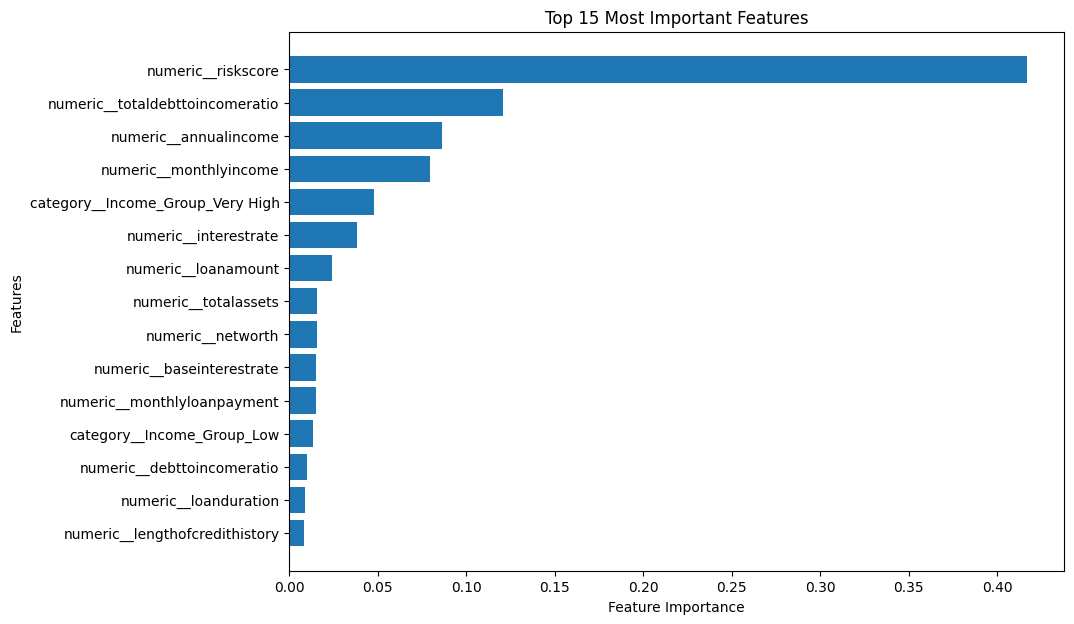

In [ ]:
# visualizing feature importance
top15 = feature_importance.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")

plt.ylabel("Features")

plt.title("Top 15 Most Important Features")

plt.show()

## **Comparing Cross Validation vs Test Performance**

In [ ]:
evaluation_summary = pd.DataFrame({
    "Metric":[
        "Cross Validation F1",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1"
    ],
    "Score":[
        cv_scores.mean(),
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

evaluation_summary

,Metric,Score
0,Cross Validation F1,0.976032
1,Test Accuracy,0.989250
2,Test Precision,0.984093
3,Test Recall,0.970711
4,Test F1,0.977357


**Overal Interpretation**\
The Random Forest classifier achieved excellent predictive performance, with a test accuracy of 98.93% and an F1-score of 97.74%. The model also achieved a mean cross-validation F1-score of 97.60%, which is very close to the test F1-score. This consistency indicates that the model generalizes well to unseen data and shows minimal evidence of overfitting. Overall, the model provides a reliable and robust approach for predicting loan approval decisions based on applicant financial and credit-related characteristics.

# **Recommendations**

Based on the findings of this analysis, the following recommendations are proposed:

1. **Adopt the model as a decision-support tool.** The Random Forest classifier demonstrated excellent predictive performance, achieving a **test accuracy of 98.93%, a precision of 98.41%, a recall of 97.07%, and an F1-score of 97.74%**. Additionally, the model achieved a mean cross-validation F1-score of 97.60%, indicating consistent performance across multiple training folds and strong generalization to unseen data. Rather than replacing human judgment, the model should be integrated as a decision-support tool to assist loan officers by providing fast, consistent, and data-driven loan approval recommendations while allowing for human oversight in exceptional cases.

2. **Prioritize financial risk indicators during loan evaluation.** Feature importance analysis revealed that **Risk Score, Total Debt-to-Income Ratio, Monthly Income, Annual Income, and Interest Rate** were the most influential factors affecting loan approval predictions. Financial institutions should continue prioritizing these variables during the loan assessment process, as they provide the strongest indication of an applicant's repayment capacity and overall credit risk.

3. **Strengthen affordability assessments.** The model highlights the importance of affordability-related variables, including **loan amount, monthly loan payment, debt-to-income ratio, interest rate, net worth, and total assets**. Incorporating these indicators into lending policies can improve credit risk assessment by ensuring that approved applicants have sufficient financial capacity to meet their repayment obligations while minimizing the likelihood of loan default.

4. **Monitor model performance regularly.** Although the model demonstrated excellent predictive performance, borrower behavior, lending policies, and economic conditions evolve over time. Regular monitoring of model performance, combined with periodic retraining using recent loan application data, will help maintain prediction accuracy and ensure that the model remains relevant under changing market conditions.

5. **Maintain fairness and transparency.** Although demographic variables contributed relatively little to the model's predictions, the institution should continue monitoring model performance across different applicant groups to ensure equitable lending decisions and compliance with responsible lending practices.

# **Potential Improvements**

While the Random Forest model achieved excellent predictive performance, several opportunities exist to further enhance the solution.

1. Future work could evaluate additional machine learning algorithms, such as Gradient Boosting, XGBoost, LightGBM, and CatBoost, to determine whether they provide improved predictive performance or computational efficiency.

2. More advanced feature engineering techniques, including interaction variables and derived financial indicators, could also be explored to capture additional relationships within the data.

3. Although GridSearchCV successfully identified an improved set of hyperparameters, future optimization could employ RandomizedSearchCV or Bayesian optimization to search larger hyperparameter spaces more efficiently.

4. Model explainability techniques such as SHAP or LIME could also be incorporated to provide more transparent explanations for individual loan approval decisions, increasing stakeholder trust and supporting regulatory requirements.

5. From an operational perspective, the model should be retrained periodically using recent loan application data to adapt to changing economic conditions, lending policies, and customer behaviour.

6. Continuous monitoring of predictive performance and fairness across different applicant segments should also be implemented to detect concept drift, maintain model reliability, and ensure equitable lending decisions over time.

7. Finally, future studies could incorporate external economic indicators, such as inflation rates, unemployment levels, and market interest rates, to improve the model's ability to respond to changing macroeconomic conditions and further strengthen its predictive capability.

# **Conclusion**

This project successfully developed a machine learning solution for predicting loan approval decisions using historical applicant data. A comprehensive data science workflow was followed, beginning with exploratory data analysis and data preprocessing, followed by feature engineering, model development, hyperparameter tuning, and final model evaluation.

The tuned Random Forest classifier demonstrated outstanding predictive performance, achieving an accuracy of 98.82%, a precision of 98.51%, a recall of 96.51%, and an F1-score of 97.50% on the test dataset. The close agreement between the cross-validation and test-set performance indicates that the model generalizes well to unseen data and exhibits minimal evidence of overfitting.

Feature importance analysis revealed that financial and credit-related variables, particularly Risk Score, Total Debt-to-Income Ratio, Monthly Income, and Annual Income, were the most influential predictors of loan approval. These findings align with established credit risk assessment practices and demonstrate that the model bases its decisions primarily on applicants' financial strength rather than demographic characteristics.

Overall, the results indicate that the proposed model has strong potential to support loan approval decisions by improving consistency, reducing manual effort, and enhancing risk assessment. When integrated alongside existing lending policies and expert judgment, the model can contribute to more informed, efficient, and reliable credit decision-making.